In [1]:
import yaml
import numpy as np
from TraceSimulator import NoiseGenerator
import matplotlib.pyplot as plt


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
ng = NoiseGenerator(config)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
noise_trace = ng.generate_noise(390_625_000)
noise_trace32 = noise_trace.astype(np.float32)


In [3]:
import numpy as np

# Start with zeros in float32 to save memory
total_trace = np.zeros(390_625_000, dtype=np.float32)

for _ in range(37):
    noise_trace = ng.generate_noise(390_625_000).astype(np.float32)
    total_trace += noise_trace


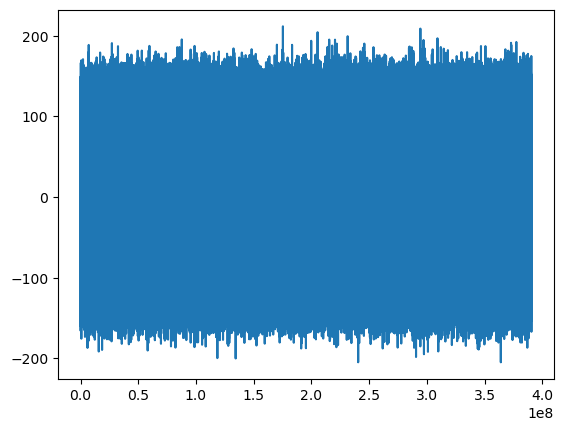

In [4]:
plt.plot(total_trace)

In [5]:
np.save("pt_noise.npy", total_trace)


In [16]:

np.save("noise_trace.npy", noise_trace32)



In [8]:
import numpy as np
from OptimumFilter import *

sampling_frequency = 3906250
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of = OptimumFilter(vac_template, noise_psd, sampling_frequency)

In [9]:
ampl_noise = vac_of.sliding_fit(noise_trace32)

In [5]:
noise_loaded = np.load("noise_trace.npy")

In [7]:
type(noise_loaded[0])

numpy.float32

In [12]:
ampl_loaded = np.load("ampl_noise.npy")
chisq_loaded = np.load("chisq_noise.npy")

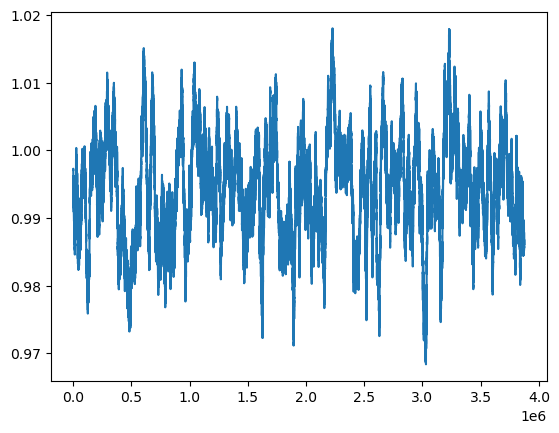

In [14]:
plt.plot(chisq_loaded)